In [1]:
%load_ext autoreload
%autoreload 2

```{toctree}
:maxdepth: 4
:caption: Contents:

# 2D case: walkthrough example


This notebook walks through a complete 2D XBeach case preparation using the `oceanicospy.models.xbeachpy` subpackage. The example is based on a **non-stationary** hydrodynamic simulation over a 2D coastal domain (Sound Bay, Caribbean coast of Colombia, May 2025).

## Workflow overview

This example user certain input files which has to be placed in `<path_case>/input/`:

| File | Description |
|---|---|
| `XBeach_domain.shp` | Polygon shapefile defining the 2D model extent |
| `TopoBathy*.csv` | X, Y, Z topobathymetry on a regular grid |
| `SpecSWAN.out` | SWAN spectral output at boundary points |
| `points_output.txt` | (optional) list of gauge output X/Y coordinates |

ERA5 winds and UHSLC water levels are **downloaded automatically** if not already cached.

## Imports

In [41]:
from oceanicospy.models import xbeachpy
from oceanicospy.plots import *

from datetime import datetime,timedelta
import warnings
warnings.filterwarnings('ignore')

import xarray as xr
import matplotlib.pyplot as plt
import shutil

## Case configuration

Three main parameters are required to set up a XBeach case:

| Parameter | Description |
|---|---|
| `path_case` | Root directory that will hold `input/`, `run/`, `output/`, `pros/` |
| `dict_ini_data` | Metadata dictionary consumed by `Initializer` |
| `ini_date` / `end_date` | Simulation window |

All user-facing settings live in plain dictionaries. The user-defined dictionary `dict_ini_data` is passed to the `Initializer` class which creates the folder structure and stamps the `params.txt` file with these settings. The expected keys for this dictionary are:

- ``case_description``: Free-form text description of the case (not used in XBeach)
- ``act_morf``: Morphological activation (0 = off)
- ``act_sedtrans``: Sediment transport activation (0 = off)
- ``act_wavemodel``: Spectral wave model activation (1 = surfbeat)
- ``dims``: Number of dimensions (2 = 2D)

In [3]:
# ── path to the case root ─────────────────────────────────────────────────────
path_case = '../../data/model_runs/2D_xbeach/' # It has to end with a slash. The folder structure will be created inside this path.

# ── case-level flags written into params.txt ──────────────────────────────────
ini_case_data = dict(
    case_description='2D Sound Bay - San Andres',
    act_morf=0,
    act_sedtrans=0,
    act_wavemodel=1,
    dims=2
)

# ── simulation period ─────────────────────────────────────────────────────────
ini_date = datetime(2025, 5, 9, 4)
end_date = datetime(2025, 5, 10, 4)

## Initialization

`Initializer` does two things:

1. **`create_folders`**: creates the project directory tree: `input/`, `pros/`, `run/`, and `output/` under `path_case`.  
   If `run/` or `output/` already exist they are **wiped and re-created** to avoid stale files from a previous attempt.

2. **`replace_ini_data`**: copies the bundled `params_base.txt` template into `run/params.txt` and substitutes the flags from `ini_case_data`.  
   Any key not supplied by the user falls back to the package defaults in `xbeachpy/utils/defaults.py`.

In [4]:
case = xbeachpy.Initializer(
    root_path=path_case,
    dict_ini_data=ini_case_data,
    ini_date=ini_date,
    end_date=end_date
)
case.create_folders()
case.replace_ini_data()

*** Initializing XBeach model ***


	*** Creating project folder structure ***


	*** Copying base XBeach configuration file into run folder ***



After this step the folder tree looks like:

```
path_case/
├── input/           ← place your static input files here
├── pros/
├── run/
│   └── params.txt   ← generated from the bundled template
└── output/
```

## Generating the grid

`xbeachpy` has a flexible grid generation utility called `GridMaker` that can build profiles or rectangular grids. For this example we will build a 1D profile

<!-- For this purpose method from `GridMaker.build_rectangular_grid()` which reads the bounding box of a user-defined shapefile placed in the input folder and lays out a uniform 2D grid. The output files from the grid generator methods are `x.grd` and `y.grd`; they are written into `run/`.
 -->
```{hint}
if you already have pre-built `.grd` files for x and y direction, you can place both inside `input/` and `GridMaker` will detect them, copy them to `run/`, and skip grid construction entirely.
```

In [5]:
grid_params_case = dict(thetamin=0, thetamax=190, dtheta=10, alfa = 180)

```{hint}
The grid parameters for the frequency-direction space should be defined in a dictionary and passed to the `GridMaker` constructor. The expected keys are:
- `thetamax`: maximum wave direction (degrees)
- `thetamin`: minimum wave direction (degrees)
- `dtheta`: wave direction step (degrees)
- `alfa`: angle of the grid with respect to the x-axis (degrees)
```

In [6]:
case_grid = xbeachpy.preprocess.GridMaker(init=case, grid_params=grid_params_case, coordinates_type="relative")

`GridMaker`has two main properties for grid construction:

- `build_rectangular_grid` — builds a uniform grid based on the bounding box of a shapefile. This property retrieves a '`Grid`' object from GIS module and it can be built using the method `from_shapefile()`.
- `build_profile` — builds a 1D profile grid based on a user-defined transect and resolution. This property retrieves a '`ProfileAxis`' object from GIS module and it can be built using the two methods defined in its class: `from_coordinates()` and `from_length()`.

In [7]:
grid_object = case_grid.build_rectangular_grid.from_shapefile(source_file='XBeach_domain.shp',dx=10,dy=10)

A quick inspection to `grid_object` shows that it is a `Grid` object with the expected attributes:

In [8]:
grid_object.relative_x_coordinates

,0,1,2,3,4,5,6,7,8,9,...,91,92,93,94,95,96,97,98,99,100
0,0.0,10.0,20.0,30.0,40.0,50.0,60.0,70.0,80.0,90.0,...,910.0,920.0,930.0,940.0,950.0,960.0,970.0,980.0,990.0,1000.0
1,0.0,10.0,20.0,30.0,40.0,50.0,60.0,70.0,80.0,90.0,...,910.0,920.0,930.0,940.0,950.0,960.0,970.0,980.0,990.0,1000.0
2,0.0,10.0,20.0,30.0,40.0,50.0,60.0,70.0,80.0,90.0,...,910.0,920.0,930.0,940.0,950.0,960.0,970.0,980.0,990.0,1000.0
3,0.0,10.0,20.0,30.0,40.0,50.0,60.0,70.0,80.0,90.0,...,910.0,920.0,930.0,940.0,950.0,960.0,970.0,980.0,990.0,1000.0
4,0.0,10.0,20.0,30.0,40.0,50.0,60.0,70.0,80.0,90.0,...,910.0,920.0,930.0,940.0,950.0,960.0,970.0,980.0,990.0,1000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,0.0,10.0,20.0,30.0,40.0,50.0,60.0,70.0,80.0,90.0,...,910.0,920.0,930.0,940.0,950.0,960.0,970.0,980.0,990.0,1000.0
107,0.0,10.0,20.0,30.0,40.0,50.0,60.0,70.0,80.0,90.0,...,910.0,920.0,930.0,940.0,950.0,960.0,970.0,980.0,990.0,1000.0
108,0.0,10.0,20.0,30.0,40.0,50.0,60.0,70.0,80.0,90.0,...,910.0,920.0,930.0,940.0,950.0,960.0,970.0,980.0,990.0,1000.0
109,0.0,10.0,20.0,30.0,40.0,50.0,60.0,70.0,80.0,90.0,...,910.0,920.0,930.0,940.0,950.0,960.0,970.0,980.0,990.0,1000.0


In [9]:
grid_object.relative_y_coordinates

,0,1,2,3,4,5,6,7,8,9,...,91,92,93,94,95,96,97,98,99,100
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,...,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0
2,20.0,20.0,20.0,20.0,20.0,20.0,20.0,20.0,20.0,20.0,...,20.0,20.0,20.0,20.0,20.0,20.0,20.0,20.0,20.0,20.0
3,30.0,30.0,30.0,30.0,30.0,30.0,30.0,30.0,30.0,30.0,...,30.0,30.0,30.0,30.0,30.0,30.0,30.0,30.0,30.0,30.0
4,40.0,40.0,40.0,40.0,40.0,40.0,40.0,40.0,40.0,40.0,...,40.0,40.0,40.0,40.0,40.0,40.0,40.0,40.0,40.0,40.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,1060.0,1060.0,1060.0,1060.0,1060.0,1060.0,1060.0,1060.0,1060.0,1060.0,...,1060.0,1060.0,1060.0,1060.0,1060.0,1060.0,1060.0,1060.0,1060.0,1060.0
107,1070.0,1070.0,1070.0,1070.0,1070.0,1070.0,1070.0,1070.0,1070.0,1070.0,...,1070.0,1070.0,1070.0,1070.0,1070.0,1070.0,1070.0,1070.0,1070.0,1070.0
108,1080.0,1080.0,1080.0,1080.0,1080.0,1080.0,1080.0,1080.0,1080.0,1080.0,...,1080.0,1080.0,1080.0,1080.0,1080.0,1080.0,1080.0,1080.0,1080.0,1080.0
109,1090.0,1090.0,1090.0,1090.0,1090.0,1090.0,1090.0,1090.0,1090.0,1090.0,...,1090.0,1090.0,1090.0,1090.0,1090.0,1090.0,1090.0,1090.0,1090.0,1090.0


If you want to check the metadata was entered into the `params.txt` file you can use a property called `metadata`

In [10]:
case_grid.metadata

{'xfilepath': 'x.grd', 'yfilepath': 'y.grd', 'meshes_x': 100, 'meshes_y': 110}

The `metadata` dictionary contains the relevant information about the grid that was either generated or copied from `input/`. The expected keys are:

```code_block:: python
{
    'xfilepath': 'x.grd',
    'yfilepath': 'y.grd',
    'meshes_x' : <int>,   # number of cells in the x-direction
    'meshes_y' : <int>    # number of cells in the y-direction
}
```

Finally the data is written to `run/` as `x.grd` and `y.grd` files, which are the expected grid files for XBeach. The grid section of `params.txt` is also updated with the relevant metadata.

In [11]:
case_grid.fill_grid_section()


*** Adding/Editing grid information in params file ***



## Setting up the bathymetry

The `BathyMaker` class provides methods for preprocessing bathymetry data and to upload existing bathymetry files. For this 2D case we will use an existing `.dep` file placed in `input/` and let `BathyMaker` copy it to `run/` and update the relevant metadata in `params.txt`.

In [12]:
case_bathy = xbeachpy.preprocess.BathyMaker(init=case)

`load_existing_dep` expects the filename of the `.dep` file as an argument. The file should be placed in `input/`. After this step the bathymetry file is copied to `run/` and the metadata dictionary is updated and returned.

In [13]:
case_bathy.load_existing_dep(dep_filename='bathymetry.dep')

{'depfilepath': 'bathymetry.dep'}

In [14]:
case_bathy.fill_bathy_section()


*** Adding/Editing bathymetry information in params file ***



## Configurating wind forcing (ERA5)

`WindForcing` class integrates directly with different data fetcher classes like `oceanicospy.downloads.ERA5Downloader`:

Similar to `swanpy` subpackage, `WindForcing` has two main methods for handling ERA5 wind data:
- **`get_winds_from_ERA5()`** — downloads hourly U10/V10 from the CDS API for the bounding box defined in `wind_dict`. If the NetCDF file already exists in `input/` the download is skipped.
- **`write_ERA5_ascii()`** — converts the NetCDF to a two-column (time [s], speed [m/s], direction [°N]) ASCII file and copies/links it into `run/`.  

The `wind_dict` should contain the following keys similar to the one used in `swanpy`:

- `lon_ll_corner_wind`: longitude of the lower-left corner of the wind grid
- `lat_ll_corner_wind`: latitude of the lower-left corner of the wind grid
- `nx_wind`: number of grid points in the x-direction (longitude)
- `ny_wind`: number of grid points in the y-direction (latitude)
- `dx_wind`: grid spacing in the x-direction (degrees)
- `dy_wind`: grid spacing in the y-direction (degrees)

In [15]:
wind_dict = dict(lon_ll_corner_wind=278, 
                 lat_ll_corner_wind=12.3, 
                 nx_wind=24, 
                 ny_wind=24, 
                 dx_wind=0.025,
                 dy_wind=0.025)

In [16]:
case_winds = xbeachpy.preprocess.WindForcing(
    init=case,
    wind_info=wind_dict,
    use_link=False
)


*** Initializing winds ***



```{hint}
`use_link=False` copies the file; `use_link=True` creates a symlink (saves space on filesystems).

Once the class is instantiated, the two methods mentioned above are called sequentially to handle the download and processing of the wind data.

In [17]:
case_winds.get_winds_from_ERA5(utc_offset_hours=-5,format_localtime=True)

the file ../../data/model_runs/2D_xbeach/input/winds_era5.nc already exists
	 ERA5 wind data already exists, skipping download


ERA5 and CMDS downloader classes are designed to format the time in local time if `format_localtime=True` is passed as an argument. This means that the downloaded files will have their timestamps converted to local time based on the provided `utc_offset_hours`. If users do not choose to format the time in local time, they should be aware that the timestamps in the downloaded files will be in UTC, which may require additional handling when the `write_ERA5_ascii()` be called to convert the NetCDF file to XBeach ASCII format, as the time formatting in the output file will depend on the original timestamps in the NetCDF file.
```

```{info}
XBeach does not use wind fields in the same way as SWAN. Instead of spatially distributed wind forcing, XBeach expects a single time series of wind speed and direction at a representative location. Therefore, the `write_ERA5_ascii()` method extracts the wind data at a single grid point (either specified by the user or defaulting to the last point in the dataset) and writes it in a format suitable for XBeach.

In [18]:
case_winds.write_ERA5_ascii(
    era5_filename='winds_era5_localtime.nc',
    ascii_filename='winds.wnd',
    lon_target=-81.706,
    lat_target=12.5204
)
case_winds.fill_wind_section()

	 ERA5 wind data converted to ASCII format and saved as winds.wnd

*** Adding/Editing winds information in params file ***



##  Setting up the water level forcing

`WaterLevelForcing` is a utility that connects to the **University of Hawaii Sea Level Center (UHSLC)** research-quality gauge archive and downloads water level data for a specified station and time window.



The following steps are involved in setting up the water level forcing:

1. **Downloading** hourly tide-gauge data for the simulation window from UHSLC.
2. **Converting** the CSV to a time series XBeachASCII water-level file (one value per timestep).
3. **Writing** the tide section of `params.txt` to point to the generated water level file.

The San Andres UHSLC station code is **737** according to the [UHSLC station list](https://uhslc.soest.hawaii.edu/stations/).

In [19]:
case_wl = xbeachpy.preprocess.WaterLevelForcing(init=case, use_link=False)
df_wl = case_wl.get_waterlevel_from_UHSLC(station_id=737)


*** Initializing water levels ***

the file ../../data/model_runs/2D_xbeach/input/h737.csv already exists
	 UHSLC water level data already exists, skipping download


```{warning}
Unlike the `WindForcing` class, the method `get_waterlevel_from_UHSLC` in the `WaterLevelForcing` class returns a data structure, not a file. This is because sometimes the pd.DataFrame containing the water level data needs to be manipulated before being written to an ASCII file and this manipulation can be case-specific per station.

Particularly for this station, it was found that the water level data from station `737` was affected by a sudden -2 m shift between 1997 and 2018. This was likely due to a change in the reference point of the gauge or a similar issue. To correct for this, a mask was applied to the DataFrame to identify the affected time range and subtract 2 m from the depth values during that period.
```

In [20]:
# mask application
correction_mask = (
    (df_wl.index >= datetime(1997, 1, 1, 0)) &
    (df_wl.index <= datetime(2018, 12, 31, 18))
)
df_wl.loc[correction_mask, "depth[m]"] -= 2.0

case_wl.write_UHSLC_ascii(df_wl, 'water_levels.wl')
case_wl.fill_wl_section()

	 UHSLC water level data converted to ASCII format and saved as water_levels.wl

*** Adding/Editing water level information in params file ***



## Defining the wave boundary conditions

This case uses non-stationary wave boundary conditions derived from a SWAN spectral output file (`SpecSWAN.out`). The `BoundaryConditions` class provides a method called `spectra_from_swan()` that processes this file and prepares the necessary input for XBeach.


1. In ordet to follows the XBeach conventions, each site must has its time time series as individual `.sp2` files. Additionally, each boundary point will have its own directory `run/bounds_conds/point_<i>/` where `<i>` is the point number. All the `.sp2` files must be placed inside the corresponding `point_<i>/` directory.
2. All the .sp2 files are written to their respective directories and they are properly referenced in the `filelist_<i>.txt` files.
3. Finally, a `loclist.txt` maps each boundary location to its corresponding filelist.

In [21]:
case_bounds = xbeachpy.preprocess.BoundaryConditions(init=case)

*** Cleaning Boundary Conditions ***
*** Initializing Boundary Conditions ***


We invoke the `spectra_from_swan()` method to process the SWAN output and generate the necessary files for XBeach. Assuming the SWAN output contains spectral data for multiple boundary points, the method will iterate through each point, extract the relevant time series, and save them in the appropriate format and directory structure required by XBeach. The input filename where the swan outputs are stored is passed as an argument to the method including its extension (e.g., `SpecSWAN.out`). This input file is expected to be placed in the `input/` directory of the case.

In [22]:
case_bounds.spectra_from_swan(input_filename='SpecSWAN.out',
                              location_points=[(0,0),(0,-100),(0,-200),
                                               (0,-300),(0,-400),(0,-500),(0,-600),(0,-700),
                                               (0,-800),(0,-900),(0,-1000),(0,-1100)],
                              point_indexes=range(3,15)) 

```{hint}
We can also use the `point_indexes` argument to specify which points from the SWAN output should be processed. If `point_indexes` is not provided, the method will process all available points in the SWAN output. As the name says, the indexes in `point_indexes` should correspond to the position of the points in the SWAN output file, starting from 0. For example, if you want to process the first three points, you would use `point_indexes=range(3)`. If you want to process points 3 to 14, you would use `point_indexes=range(3,15)`.
```

We can finally replace the required placeholders in the `params.txt` file with the corresponding flags for the wave boundary conditions.

In [23]:
case_bounds.fill_boundaries_section()


*** Adding/Editing boundary information for domain in configuration file ***



## Output and compilation configuration

For this section the parameters for the compilation and output settings for the case have to be defined.

`CaseRunner` finalises `params.txt` with the required output and computation settings:

| Method | Purpose |
|---|---|
| `write_output_file()` | set the output NetCDF filename |
| `write_output_points()` | read gauge coordinates from `points_output.txt` and embed them |
| `select_global_vars()` | choose field variables written at `tintg` |
| `select_point_vars()` | choose time-series variables at the gauge locations |
| `fill_computation_section()` | compute `tstop` from the start/end dates and write remaining params |

Before the compilation step, a compilation data dictionary must be defined with the following keys:

- `tint_value` : Output interval for time-series data at points (seconds)
- `tintg_value` : Output interval for instantaneous field data (seconds)

Additionally, the definition of `tstart_value` is optional, if not provided the code will default to `ini_date` as the initialization step for outputs. `tstart_value` can be used to skip the initial part of the simulation for output purposes, which is useful for non-stationary cases with a certain spin-up period.

In [24]:
# ── computation / output settings ─────────────────────────────────────────────
comp_data_nonstat = dict(
    tint_value=3600,    # output interval [s]
    tintg_value=3600,   # global output interval [s]
    tstart_value=10800   # start time for outputs [s]
)

Once the `comp_data_nonstat` dictionary is defined, the `CaseRunner` methods are called sequentially to set up the output configuration and finalise the `params.txt` file for compilation.

In [25]:
case_output = xbeachpy.execution.CaseRunner(
    init=case,
    dict_comp_data=comp_data_nonstat
)


*** Initializing Case Runner ***



If the user wants to get output at specific points, a plain-text file  must be placed in the `input/` folder with the following format:

```
x_coordinate,y_coordinate
762500,1385500
762600,1385500
...
```

The coordinates must follow the model grid reference system. For this case, the file is named `points_output.txt`.


In [26]:
# filepath for the output file with the global 2D fields (netCDF format)
case_output.write_output_file(filename='SoundBay2D.nc')

# selection of the variables to be included in the global output file
case_output.select_global_vars(list_vars=['zs','hh','zb0','H','u','v'])

# definition of output points
case_output.write_output_points(filename='points_output.txt')

# selection of the variables to be included in the output file with time-series at points
case_output.select_point_vars(list_vars=['zs','hh','zb0','H','u','v'])

```{note}
The variable names to be included in the output files can be selected from the list of available variables in XBeach. That is, they follow the same naming convention.

In [27]:
case_output.fill_computation_section()

In [35]:
shutil.copy('../../data/temp/2D_xbeach_output/SoundBay2D.nc', 
                '../../data/model_runs/2D_xbeach/output/')

'../../data/model_runs/2D_xbeach/output/SoundBay2D.nc'

## Post-processing (after the run)

Once the case is run and the output NetCDF file is generated and placed in the `output` directory, the post-processing work can be done using libraries like `xarray` and `matplotlib` directly. 

In [36]:
ds_output = xr.open_dataset(f'{path_case}output/SoundBay2D.nc')

A quick view to the output dataset shows that it contains the expected variables and dimensions for spatial and point outputs.
```{hint}

In [37]:
ds_output

<xarray.Dataset> Size: 14MB
Dimensions:      (ny: 111, nx: 101, globaltime: 25, pointtime: 25, points: 3)
Coordinates:
    globalx      (ny, nx) float64 90kB ...
    globaly      (ny, nx) float64 90kB ...
  * globaltime   (globaltime) float64 200B 0.0 3.6e+03 ... 8.28e+04 8.64e+04
  * pointtime    (pointtime) float64 200B 0.0 3.6e+03 ... 8.28e+04 8.64e+04
    pointx       (points) float64 24B ...
    pointy       (points) float64 24B ...
Dimensions without coordinates: ny, nx, points
Data variables: (12/17)
    _parameters  float64 8B ...
    zs           (globaltime, ny, nx) float64 2MB ...
    hh           (globaltime, ny, nx) float64 2MB ...
    zb0          (globaltime, ny, nx) float64 2MB ...
    H            (globaltime, ny, nx) float64 2MB ...
    u            (globaltime, ny, nx) float64 2MB ...
    ...           ...
    point_zs     (pointtime, points) float64 600B ...
    point_hh     (pointtime, points) float64 600B ...
    point_zb0    (pointtime, points) float64 600B ...
    point_H      (pointtime, points) float64 600B ...
    point_u      (pointtime, points) float64 600B ...
    point_v      (pointtime, points) float64 600B ...
Attributes:
    Conventions:     CF-1.4
    Producer:        XBeach littoral zone wave model (http://www.xbeach.org)
    Build-Revision:  
    Build-Date:      Sat Nov 26 18:36:59 UTC 2022
    URL:

The xarray dataset will be split into two main groups: one for the field outputs (e.g., water levels, velocities) and another for the point outputs (e.g., time series at gauge locations). The field outputs will have dimensions corresponding to time, x, and y, while the point outputs will have dimensions corresponding to time and the number of points. This structure allows for easy access and analysis of both spatial and temporal data from the XBeach simulation.

In [38]:
ds_field = ds_output[[var for var in ds_output.data_vars if ds_output[var].ndim > 2]]
ds_point = ds_output[[var for var in ds_output.data_vars if ds_output[var].ndim == 2]]

In [48]:
ds_field.H[1,:,:]

<xarray.DataArray 'H' (ny: 111, nx: 101)> Size: 90kB
array([[0.566575, 0.534304, 0.583416, ...,      nan,      nan,      nan],
       [0.566575, 0.534304, 0.583416, ...,      nan,      nan,      nan],
       [0.418554, 0.525377, 0.624847, ...,      nan,      nan,      nan],
       ...,
       [0.1254  , 0.178709, 0.325201, ...,      nan,      nan,      nan],
       [0.137225, 0.219852, 0.344227, ...,      nan,      nan,      nan],
       [0.137225, 0.219852, 0.344227, ...,      nan,      nan,      nan]],
      shape=(111, 101))
Coordinates:
    globalx     (ny, nx) float64 90kB 0.0 -10.0 -20.0 ... -980.0 -990.0 -1e+03
    globaly     (ny, nx) float64 90kB 0.0 1.225e-15 ... -1.1e+03 -1.1e+03
    globaltime  float64 8B 3.6e+03
Dimensions without coordinates: ny, nx
Attributes:
    units:      m
    long_name:  Hrms wave height based on instantaneous wave energy

### Spatial field plots

Contourf maps of the global field variables at a selected output time step. The `H` variable stores Hrms and `u` the cross-shore velocity component.

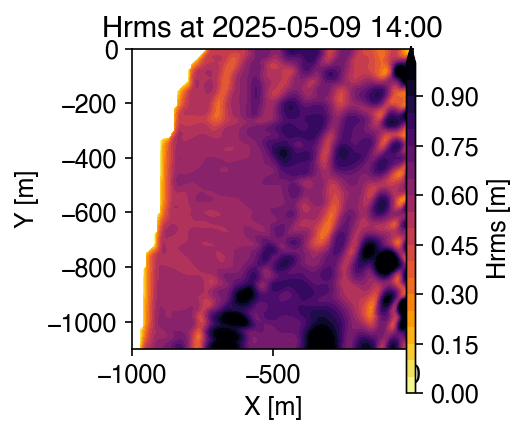

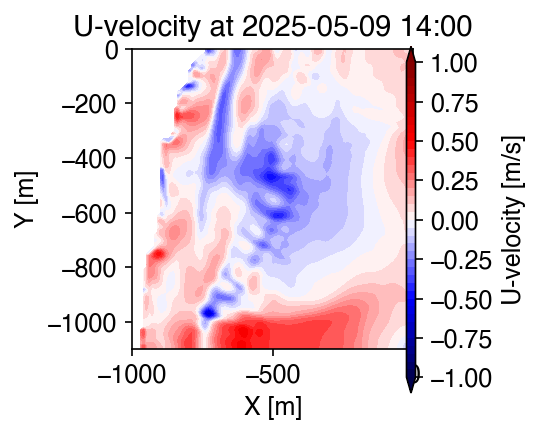

In [42]:
ini_date = datetime(2025, 5, 9, 4)
time = np.array([ini_date + timedelta(seconds=int(s)) for s in ds_field.globaltime.values])

time_index = 10

# ── Hrms field ─────────────────────────────────────────────────────────────────
H_data = ds_field['H'].values[time_index, :, :]
H_levels = np.arange(0, 1.05, 0.05)

fig, ax = plt.subplots(figsize=(3, 3))
cf = ax.contourf(ds_field.globalx, ds_field.globaly, H_data,
                 levels=H_levels, extend='max', cmap='inferno_r')
pos = ax.get_position()
cax = fig.add_axes([pos.x1 + 0.02, pos.y0, 0.02, pos.height])
fig.colorbar(cf, cax=cax, label='Hrms [m]')
ax.set_title(f'Hrms at {time[time_index]:%Y-%m-%d %H:%M}', fontsize=14)
ax.set(xlabel='X [m]', ylabel='Y [m]')
ax.ticklabel_format(useOffset=False, style='plain', axis='both')
plt.tight_layout()
plt.show()

# ── U-velocity field ───────────────────────────────────────────────────────────
U_data = ds_field['u'].values[time_index, :, :]
U_levels = np.arange(-1, 1.05, 0.05)

fig, ax = plt.subplots(figsize=(3, 3))
cf = ax.contourf(ds_field.globalx, ds_field.globaly, U_data,
                 levels=U_levels, extend='both', cmap='seismic')
pos = ax.get_position()
cax = fig.add_axes([pos.x1 + 0.02, pos.y0, 0.02, pos.height])
fig.colorbar(cf, cax=cax, label='U-velocity [m/s]')
ax.set_title(f'U-velocity at {time[time_index]:%Y-%m-%d %H:%M}', fontsize=14)
ax.set(xlabel='X [m]', ylabel='Y [m]')
ax.ticklabel_format(useOffset=False, style='plain', axis='both')
plt.tight_layout()
plt.show()

### Time series at a point location

Point output variables (prefix `point_`) have dimensions `(pointtime, points)`. The cell below plots the Hrms time series at the first recorded gauge location.

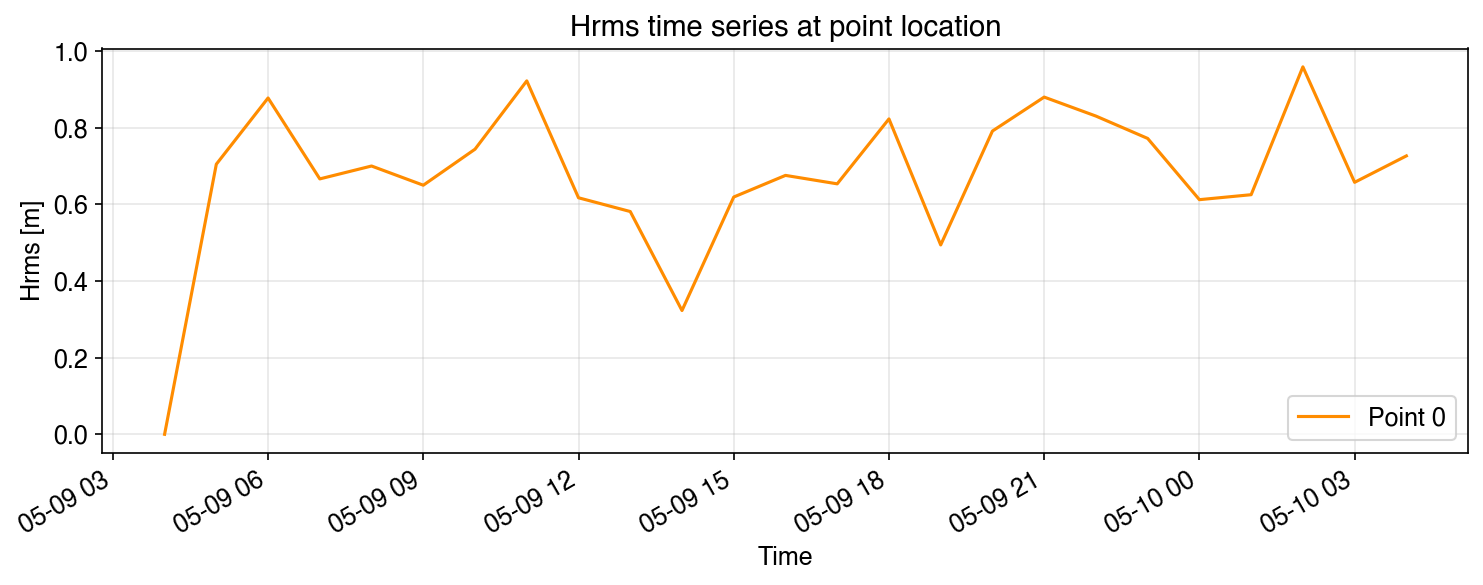

In [44]:
t = np.array([ini_date + timedelta(seconds=int(s)) for s in ds_point.pointtime.values])

point_index = 0

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t, ds_point['point_H'][:, point_index].values, color='darkorange', lw=1.5,
        label=f'Point {point_index}')
ax.set_title('Hrms time series at point location', fontsize=14)
ax.set(xlabel='Time', ylabel='Hrms [m]')
ax.grid(alpha=0.3)
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()